In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("../dataset/updated_pollution_dataset.csv")

In [4]:
from sklearn.preprocessing import LabelEncoder
df["Air Quality"] = df["Air Quality"].map({
    "Good": 0,
    "Moderate": 0,
    "Poor": 1,
    "Hazardous": 1
})

In [5]:
X = df.drop("Air Quality", axis=1)
y = df["Air Quality"]

In [6]:
class LogisticRegressionScratch:
    def __init__(self,learning_rate = 0.1, iterations = 10000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    def compute_cost(self,y,y_pred):
        m = len(y)
        epsilon = 1e-9
        cost = -(1/m)*np.sum(y*np.log(y_pred+epsilon)+(1-y)*np.log(1-y_pred+epsilon))
        return cost
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.iterations):
            linear_output = np.dot(X,self.weights)+self.bias
            y_pred = self.sigmoid(linear_output)
            cost = self.compute_cost(y,y_pred)
            self.cost_history.append(cost)
            dw = (1/n_samples)*np.dot(X.T,(y_pred-y))
            db = (1/n_samples)*np.sum(y_pred-y)
            w_new = self.weights - self.learning_rate*dw
            self.weights = w_new
            b_new = self.bias - self.learning_rate*db
            self.bias = b_new
            if i % 500 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")
    def predict_proba(self,X):
        linear_output = np.dot(X,self.weights)+self.bias
        return self.sigmoid(linear_output)
    def predict(self,X):
        probabilities = self.predict_proba(X)
        return np.array([1 if p>=0.5 else 0 for p in probabilities])

In [7]:
X.shape, y.shape

((5000, 9), (5000,))

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = LogisticRegressionScratch(learning_rate=0.1,iterations = 10000)
model.fit(X_train,y_train)

Iteration 0: Cost = 0.6931
Iteration 500: Cost = 0.1104
Iteration 1000: Cost = 0.0939
Iteration 1500: Cost = 0.0871
Iteration 2000: Cost = 0.0833
Iteration 2500: Cost = 0.0809
Iteration 3000: Cost = 0.0792
Iteration 3500: Cost = 0.0780
Iteration 4000: Cost = 0.0771
Iteration 4500: Cost = 0.0764
Iteration 5000: Cost = 0.0758
Iteration 5500: Cost = 0.0753
Iteration 6000: Cost = 0.0749
Iteration 6500: Cost = 0.0746
Iteration 7000: Cost = 0.0743
Iteration 7500: Cost = 0.0740
Iteration 8000: Cost = 0.0738
Iteration 8500: Cost = 0.0736
Iteration 9000: Cost = 0.0734
Iteration 9500: Cost = 0.0732


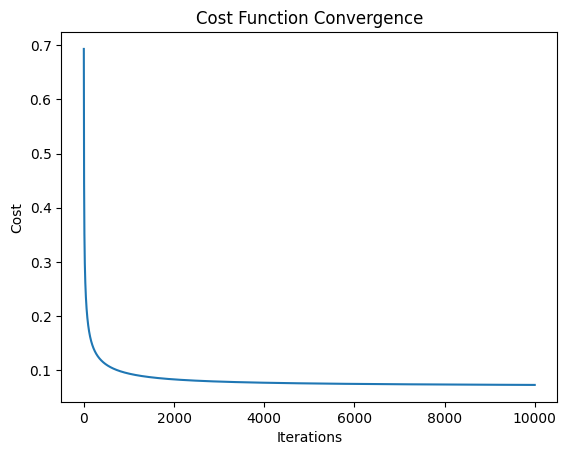

In [10]:
import matplotlib.pyplot as plt
plt.plot(model.cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.975
Precision: 0.9533333333333334
Recall   : 0.9629629629629629
F1 Score : 0.9581239530988275

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       703
           1       0.95      0.96      0.96       297

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.98      0.97      0.98      1000

